In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
from scipy import stats
from datetime import date, datetime, timedelta

import seaborn as sns
import matplotlib.pyplot as plt

from io import BytesIO
import base64
#from IPython.core.display import HTML

import dataframe_image as dfi

# Tables as Data Visualization

In this workshop, we will learn to use tables as a form of data visualization. While charts and graphs are powerful, tables can present detailed information in a structured format that is easier to read and compare precisely.

To design publication-ready tables, we will use pandas' `Styler` API, which exposes HTML and CSS properties for applying aesthetic formatting directly to a DataFrame.

Our dataset comes from the NYC Department of Buildings (DOB) and contains all reported building violations in 2025. Let's get started.

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/nickxscott/INFO658/refs/heads/main/notebooks/data/DOB_Violations_20260301.csv')
df

,ISN_DOB_BIS_VIOL,BORO,BIN,BLOCK,LOT,ISSUE_DATE,VIOLATION_TYPE_CODE,VIOLATION_NUMBER,HOUSE_NUMBER,STREET,DISPOSITION_DATE,DISPOSITION_COMMENTS,DEVICE_NUMBER,DESCRIPTION,ECB_NUMBER,NUMBER,VIOLATION_CATEGORY,VIOLATION_TYPE
0,2787713,3,3041236,1519,29,20250109,IMEGNCY,18938,298,MARION STREET,20250304.0,"DISMISSED, SIDEWALK SHED ERECTED",NaN,INSTALL A SIDEWALK SHED APPROXIMATED 20 FEET A...,NaN,V*010925IMEGNCY18938,V*-DOB VIOLATION - DISMISSED,IMEGNCY-IMMEDIATE EMERGENCY ...
1,2788952,2,2114613,2379,7,20250122,AEUHAZ1,00175,404,EAST 158 STREET,20251031.0,ECB DISMISSED,NaN,FAILURE TO CERTIFY CORRECTION ON IMMEDIATELY H...,39130865H,V*012225AEUHAZ100175,V*-DOB VIOLATION - DISMISSED,AEUHAZ1-FAIL TO CERTIFY CLASS 1 ...
2,2795652,3,3074129,3257,5,20251031,EGNCY,19716,201,WILSON AVENUE,NaN,NaN,NaN,FULLY DEMOLISH THE BUILDING AND GRADE & FENCE ...,NaN,V103125EGNCY19716,V-DOB VIOLATION - ACTIVE,EGNCY-EMERGENCY ...
3,2795216,4,4170046,8176,18,20251013,C,25-02318,53-24,241 STREET,20251031.0,OKAY TO DISMISS DOB VIO AS PER INSP BADGE ...,NaN,STRUCTURE RENDERED NON-COMPLIANT. AT TIME OF I...,NaN,V*101325C25-02318,V*-DOB VIOLATION - DISMISSED,C-CONSTRUCTION ...
4,2794799,1,1010145,590,29,20250926,IMEGNCY,19603,168,WEST 4 STREET,20251105.0,IED IS RESOLVED. WORK COMPLETED BY OWNERAND VE...,NaN,PROVIDE APPROXIMATELY 20 LINEAR FEET OF SIDEWA...,NaN,V*092625IMEGNCY19603,V*-DOB VIOLATION - DISMISSED,IMEGNCY-IMMEDIATE EMERGENCY ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29405,2816606,3,3023365,1033,43,20251118,C,SR0601NS,526,4 AVENUE,20260227.0,"NAN, BUILDING DEMOLISHED",NaN,FAILURE TO MAINTAIN BUILDING IN CODE COMPLIANT...,NaN,V*111825CSR0601NS,V*-DOB VIOLATION - DISMISSED,C-CONSTRUCTION ...
29406,2808548,3,3125915,5368,2,20251114,LBLVIO,12896,3619,15 AVENUE,20260227.0,CIANOW CRM Violation Dismissed,00038189,VIOLATION ISSUED-FAILURE TO FILE 2024 EXTERNAL...,NaN,V*111425LBLVIO12896,V*-DOB VIOLATION - DISMISSED,LBLVIO-LOW PRESSURE BOILER ...
29407,2793480,1,1006165,445,4,20250725,LANDMK,26-0087,60,2 AVENUE,20260227.0,NaN,NaN,NaN,NaN,V*072525LANDMK26-0087,V*-DOB VIOLATION - DISMISSED,LANDMK-LANDMARK ...
29408,2798651,1,1027008,1077,12,20251114,LBLVIO,02999,533,WEST 48 STREET,20260227.0,CIANOW CRM Violation Dismissed,00082955,VIOLATION ISSUED-FAILURE TO FILE 2024 EXTERNAL...,NaN,V*111425LBLVIO02999,V*-DOB VIOLATION - DISMISSED,LBLVIO-LOW PRESSURE BOILER ...


The dataset contains over 29,000 building violation records. Let's inspect the column names to understand what information is available.

In [3]:
df.columns

Index(['ISN_DOB_BIS_VIOL', 'BORO', 'BIN', 'BLOCK', 'LOT', 'ISSUE_DATE',
       'VIOLATION_TYPE_CODE', 'VIOLATION_NUMBER', 'HOUSE_NUMBER', 'STREET',
       'DISPOSITION_DATE', 'DISPOSITION_COMMENTS', 'DEVICE_NUMBER',
       'DESCRIPTION', 'ECB_NUMBER', 'NUMBER', 'VIOLATION_CATEGORY',
       'VIOLATION_TYPE'],
      dtype='object')

Two columns stand out for exploration: `VIOLATION_TYPE_CODE` and `VIOLATION_TYPE`. Let's group by both to see each unique violation category and the number of records in each.

In [4]:
df.groupby(['VIOLATION_TYPE_CODE', 'VIOLATION_TYPE']).VIOLATION_TYPE.count()

VIOLATION_TYPE_CODE  VIOLATION_TYPE                                                                          
AEUHAZ1              AEUHAZ1-FAIL TO CERTIFY CLASS 1                                         NONE                 1095
B                    B-BOILER                                                          BOILER  OPTIONAL              1
C                    C-CONSTRUCTION                                                    OTHER   OPTIONAL           5776
CLOS                 CLOS-PADLOCK                                                         NONE                      27
E                    E-ELEVATOR                                                        ELEVATORREQUIRED             30
EGNCY                EGNCY-EMERGENCY                                                       NONE                     49
EGRADE               EGRADE-FAILURE TO POST ENERGY GRADE/SCORE                              NONE                     2
FISPFCS              FISPFCS-FAILURE TO CORRECT SWARMP CO

Note that `IMEGNCY` (Immediate Emergency) violations are of particular interest, as they represent the most urgent building safety issues. We will return to this category shortly.

First, let's examine the data types for each column to check for any type mismatches that need to be addressed.

In [5]:
df.dtypes

ISN_DOB_BIS_VIOL          int64
BORO                      int64
BIN                       int64
BLOCK                     int64
LOT                       int64
ISSUE_DATE                int64
VIOLATION_TYPE_CODE      object
VIOLATION_NUMBER         object
HOUSE_NUMBER             object
STREET                   object
DISPOSITION_DATE        float64
DISPOSITION_COMMENTS     object
DEVICE_NUMBER            object
DESCRIPTION              object
ECB_NUMBER               object
NUMBER                   object
VIOLATION_CATEGORY       object
VIOLATION_TYPE           object
dtype: object

The `ISSUE_DATE` column is currently stored as an integer rather than a `datetime` type. This will cause problems for any time-based analysis. Let's inspect the raw values to understand the date format before converting.

In [6]:
df.ISSUE_DATE

0        20250109
1        20250122
2        20251031
3        20251013
4        20250926
           ...   
29405    20251118
29406    20251114
29407    20250725
29408    20251114
29409    20251114
Name: ISSUE_DATE, Length: 29410, dtype: int64

The dates are formatted as `YYYYMMDD` with no separators. We can convert this to a proper `datetime` type using `pd.to_datetime()` and specifying the format string `'%Y%m%d'`.

In [7]:
df.ISSUE_DATE = pd.to_datetime(df.ISSUE_DATE, format='%Y%m%d')

Let's verify the conversion by checking the column data types again.

In [8]:
df.dtypes

ISN_DOB_BIS_VIOL                 int64
BORO                             int64
BIN                              int64
BLOCK                            int64
LOT                              int64
ISSUE_DATE              datetime64[ns]
VIOLATION_TYPE_CODE             object
VIOLATION_NUMBER                object
HOUSE_NUMBER                    object
STREET                          object
DISPOSITION_DATE               float64
DISPOSITION_COMMENTS            object
DEVICE_NUMBER                   object
DESCRIPTION                     object
ECB_NUMBER                      object
NUMBER                          object
VIOLATION_CATEGORY              object
VIOLATION_TYPE                  object
dtype: object

## Feature Engineering

`ISSUE_DATE` is now a `datetime` type. Next, we'll extract the month name from this column to use as a grouping variable. We can do this with the `.strftime()` method using the `'%B'` format code, which returns the full capitalized month name.

Let's test this on the first 5 rows before applying it to the full dataset.

In [9]:
for index, row in df.head().iterrows():
    print(row.ISSUE_DATE.strftime("%B"), row.ISSUE_DATE)

January 2025-01-09 00:00:00
January 2025-01-22 00:00:00
October 2025-10-31 00:00:00
October 2025-10-13 00:00:00
September 2025-09-26 00:00:00


The output is correct. Now let's apply this to the full dataset by creating a new `issue_month` column.

In [10]:
month=[m.strftime("%B") for m in df.ISSUE_DATE]
df['issue_month']=month
df

,ISN_DOB_BIS_VIOL,BORO,BIN,BLOCK,LOT,ISSUE_DATE,VIOLATION_TYPE_CODE,VIOLATION_NUMBER,HOUSE_NUMBER,STREET,DISPOSITION_DATE,DISPOSITION_COMMENTS,DEVICE_NUMBER,DESCRIPTION,ECB_NUMBER,NUMBER,VIOLATION_CATEGORY,VIOLATION_TYPE,issue_month
0,2787713,3,3041236,1519,29,2025-01-09,IMEGNCY,18938,298,MARION STREET,20250304.0,"DISMISSED, SIDEWALK SHED ERECTED",NaN,INSTALL A SIDEWALK SHED APPROXIMATED 20 FEET A...,NaN,V*010925IMEGNCY18938,V*-DOB VIOLATION - DISMISSED,IMEGNCY-IMMEDIATE EMERGENCY ...,January
1,2788952,2,2114613,2379,7,2025-01-22,AEUHAZ1,00175,404,EAST 158 STREET,20251031.0,ECB DISMISSED,NaN,FAILURE TO CERTIFY CORRECTION ON IMMEDIATELY H...,39130865H,V*012225AEUHAZ100175,V*-DOB VIOLATION - DISMISSED,AEUHAZ1-FAIL TO CERTIFY CLASS 1 ...,January
2,2795652,3,3074129,3257,5,2025-10-31,EGNCY,19716,201,WILSON AVENUE,NaN,NaN,NaN,FULLY DEMOLISH THE BUILDING AND GRADE & FENCE ...,NaN,V103125EGNCY19716,V-DOB VIOLATION - ACTIVE,EGNCY-EMERGENCY ...,October
3,2795216,4,4170046,8176,18,2025-10-13,C,25-02318,53-24,241 STREET,20251031.0,OKAY TO DISMISS DOB VIO AS PER INSP BADGE ...,NaN,STRUCTURE RENDERED NON-COMPLIANT. AT TIME OF I...,NaN,V*101325C25-02318,V*-DOB VIOLATION - DISMISSED,C-CONSTRUCTION ...,October
4,2794799,1,1010145,590,29,2025-09-26,IMEGNCY,19603,168,WEST 4 STREET,20251105.0,IED IS RESOLVED. WORK COMPLETED BY OWNERAND VE...,NaN,PROVIDE APPROXIMATELY 20 LINEAR FEET OF SIDEWA...,NaN,V*092625IMEGNCY19603,V*-DOB VIOLATION - DISMISSED,IMEGNCY-IMMEDIATE EMERGENCY ...,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29405,2816606,3,3023365,1033,43,2025-11-18,C,SR0601NS,526,4 AVENUE,20260227.0,"NAN, BUILDING DEMOLISHED",NaN,FAILURE TO MAINTAIN BUILDING IN CODE COMPLIANT...,NaN,V*111825CSR0601NS,V*-DOB VIOLATION - DISMISSED,C-CONSTRUCTION ...,November
29406,2808548,3,3125915,5368,2,2025-11-14,LBLVIO,12896,3619,15 AVENUE,20260227.0,CIANOW CRM Violation Dismissed,00038189,VIOLATION ISSUED-FAILURE TO FILE 2024 EXTERNAL...,NaN,V*111425LBLVIO12896,V*-DOB VIOLATION - DISMISSED,LBLVIO-LOW PRESSURE BOILER ...,November
29407,2793480,1,1006165,445,4,2025-07-25,LANDMK,26-0087,60,2 AVENUE,20260227.0,NaN,NaN,NaN,NaN,V*072525LANDMK26-0087,V*-DOB VIOLATION - DISMISSED,LANDMK-LANDMARK ...,July
29408,2798651,1,1027008,1077,12,2025-11-14,LBLVIO,02999,533,WEST 48 STREET,20260227.0,CIANOW CRM Violation Dismissed,00082955,VIOLATION ISSUED-FAILURE TO FILE 2024 EXTERNAL...,NaN,V*111425LBLVIO02999,V*-DOB VIOLATION - DISMISSED,LBLVIO-LOW PRESSURE BOILER ...,November


The `BORO` column uses numeric codes (1–5) to identify each borough. According to the [dataset metadata](https://data.cityofnewyork.us/Housing-Development/DOB-Violations/3h2n-5cm9/about_data), each number maps to a specific borough. Let's create a `boro_name` column with the full borough names to make grouping and labeling more readable.

In [11]:
boro={1:'Manhattan', 
      2:'Bronx', 
      3:'Brooklyn',
      4:'Queens', 
      5:'Staten Island'}
df['boro_name']=df.BORO.map(boro)
df

,ISN_DOB_BIS_VIOL,BORO,BIN,BLOCK,LOT,ISSUE_DATE,VIOLATION_TYPE_CODE,VIOLATION_NUMBER,HOUSE_NUMBER,STREET,DISPOSITION_DATE,DISPOSITION_COMMENTS,DEVICE_NUMBER,DESCRIPTION,ECB_NUMBER,NUMBER,VIOLATION_CATEGORY,VIOLATION_TYPE,issue_month,boro_name
0,2787713,3,3041236,1519,29,2025-01-09,IMEGNCY,18938,298,MARION STREET,20250304.0,"DISMISSED, SIDEWALK SHED ERECTED",NaN,INSTALL A SIDEWALK SHED APPROXIMATED 20 FEET A...,NaN,V*010925IMEGNCY18938,V*-DOB VIOLATION - DISMISSED,IMEGNCY-IMMEDIATE EMERGENCY ...,January,Brooklyn
1,2788952,2,2114613,2379,7,2025-01-22,AEUHAZ1,00175,404,EAST 158 STREET,20251031.0,ECB DISMISSED,NaN,FAILURE TO CERTIFY CORRECTION ON IMMEDIATELY H...,39130865H,V*012225AEUHAZ100175,V*-DOB VIOLATION - DISMISSED,AEUHAZ1-FAIL TO CERTIFY CLASS 1 ...,January,Bronx
2,2795652,3,3074129,3257,5,2025-10-31,EGNCY,19716,201,WILSON AVENUE,NaN,NaN,NaN,FULLY DEMOLISH THE BUILDING AND GRADE & FENCE ...,NaN,V103125EGNCY19716,V-DOB VIOLATION - ACTIVE,EGNCY-EMERGENCY ...,October,Brooklyn
3,2795216,4,4170046,8176,18,2025-10-13,C,25-02318,53-24,241 STREET,20251031.0,OKAY TO DISMISS DOB VIO AS PER INSP BADGE ...,NaN,STRUCTURE RENDERED NON-COMPLIANT. AT TIME OF I...,NaN,V*101325C25-02318,V*-DOB VIOLATION - DISMISSED,C-CONSTRUCTION ...,October,Queens
4,2794799,1,1010145,590,29,2025-09-26,IMEGNCY,19603,168,WEST 4 STREET,20251105.0,IED IS RESOLVED. WORK COMPLETED BY OWNERAND VE...,NaN,PROVIDE APPROXIMATELY 20 LINEAR FEET OF SIDEWA...,NaN,V*092625IMEGNCY19603,V*-DOB VIOLATION - DISMISSED,IMEGNCY-IMMEDIATE EMERGENCY ...,September,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29405,2816606,3,3023365,1033,43,2025-11-18,C,SR0601NS,526,4 AVENUE,20260227.0,"NAN, BUILDING DEMOLISHED",NaN,FAILURE TO MAINTAIN BUILDING IN CODE COMPLIANT...,NaN,V*111825CSR0601NS,V*-DOB VIOLATION - DISMISSED,C-CONSTRUCTION ...,November,Brooklyn
29406,2808548,3,3125915,5368,2,2025-11-14,LBLVIO,12896,3619,15 AVENUE,20260227.0,CIANOW CRM Violation Dismissed,00038189,VIOLATION ISSUED-FAILURE TO FILE 2024 EXTERNAL...,NaN,V*111425LBLVIO12896,V*-DOB VIOLATION - DISMISSED,LBLVIO-LOW PRESSURE BOILER ...,November,Brooklyn
29407,2793480,1,1006165,445,4,2025-07-25,LANDMK,26-0087,60,2 AVENUE,20260227.0,NaN,NaN,NaN,NaN,V*072525LANDMK26-0087,V*-DOB VIOLATION - DISMISSED,LANDMK-LANDMARK ...,July,Manhattan
29408,2798651,1,1027008,1077,12,2025-11-14,LBLVIO,02999,533,WEST 48 STREET,20260227.0,CIANOW CRM Violation Dismissed,00082955,VIOLATION ISSUED-FAILURE TO FILE 2024 EXTERNAL...,NaN,V*111425LBLVIO02999,V*-DOB VIOLATION - DISMISSED,LBLVIO-LOW PRESSURE BOILER ...,November,Manhattan


## Exploratory Visualization

With our new columns in place, let's explore the distribution of Immediate Emergency (`IMEGNCY`) violations by borough and month. We'll filter the data to only `IMEGNCY` violations, group by `boro_name` and `issue_month`, and plot the result as a grouped bar chart.

In [12]:
df_grouped=df.loc[df.VIOLATION_TYPE_CODE=='IMEGNCY'].groupby(['boro_name', 'issue_month']).ISN_DOB_BIS_VIOL.count().reset_index(name='violation_count')
df_grouped

,boro_name,issue_month,violation_count
0,Bronx,April,11
1,Bronx,August,14
2,Bronx,December,20
3,Bronx,February,13
4,Bronx,January,5
5,Bronx,July,9
6,Bronx,June,12
7,Bronx,March,14
8,Bronx,May,12
9,Bronx,November,8


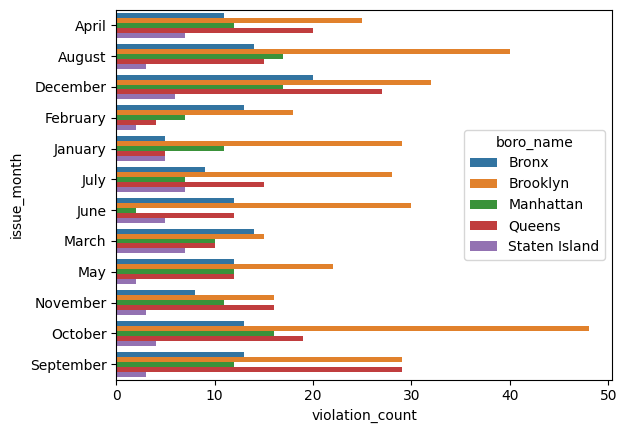

In [13]:
sns.barplot(data=df_grouped, y='issue_month', x='violation_count', hue='boro_name');

The chart is difficult to parse with this many categories. Let's swap the axes — placing borough on the y-axis and mapping months to color — to see if that improves readability.

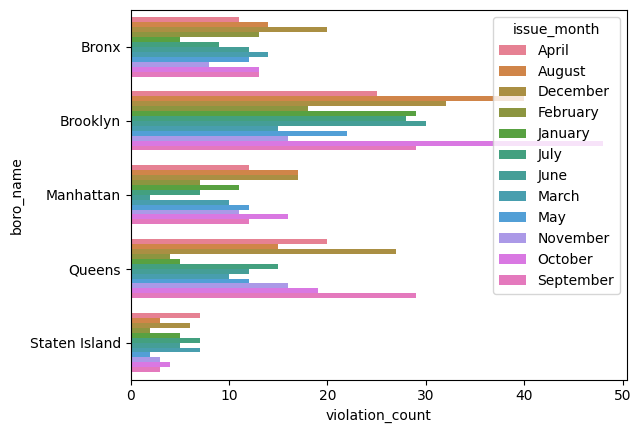

In [14]:
sns.barplot(data=df_grouped, y='boro_name', x='violation_count', hue='issue_month');

## Building the Table

The bar chart is still difficult to read with twelve months mapped to color. This is a case where a table is the better choice — it communicates the same detail with greater precision and without visual clutter.

The goal is a table with one row per borough and one column per month. We need to reshape the data from its current long format into this wide format. Let's start by constructing an empty DataFrame with the desired column names, then populate it row by row.

In [15]:
months=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_table=pd.DataFrame(columns=['boro']+months)

for b in df_grouped.boro_name.unique():
    row=[b]
    for m in months:
        c=df_grouped.loc[(df_grouped.boro_name==b) & (df_grouped.issue_month==m)].violation_count.values[0]
        row.append(c)
    df_table.loc[len(df_table)]=row
df_table

,boro,January,February,March,April,May,June,July,August,September,October,November,December
0,Bronx,5,13,14,11,12,12,9,14,13,13,8,20
1,Brooklyn,29,18,15,25,22,30,28,40,29,48,16,32
2,Manhattan,11,7,10,12,12,2,7,17,12,16,11,17
3,Queens,5,4,10,20,12,12,15,15,29,19,16,27
4,Staten Island,5,2,7,7,2,5,7,3,3,4,3,6


The per-borough monthly counts are now in place. Let's add a `Total` row showing the citywide sum for each month, then set the borough name as the index to give the table a cleaner appearance.

In [16]:
total_row=['Total']
for m in months:
    month_total=df_table[m].sum()
    total_row.append(month_total)
df_table.loc[len(df_table)]=total_row

df_table=df_table.set_index('boro')#.index_name('')
df_table.index.name=None
df_table

,January,February,March,April,May,June,July,August,September,October,November,December
Bronx,5,13,14,11,12,12,9,14,13,13,8,20
Brooklyn,29,18,15,25,22,30,28,40,29,48,16,32
Manhattan,11,7,10,12,12,2,7,17,12,16,11,17
Queens,5,4,10,20,12,12,15,15,29,19,16,27
Staten Island,5,2,7,7,2,5,7,3,3,4,3,6
Total,55,44,56,75,60,61,66,89,86,100,54,102


## Styling the Table

The table structure is complete. Now we'll use pandas' `Styler` API to add visual formatting.

An important note about the `.style` property: applying it converts the DataFrame into a `Styler` object. A `Styler` is not a DataFrame — it has different methods and cannot be used for further data manipulation. All styling will be applied together at the end.

Let's start by applying a background color gradient across each row to highlight which months have higher and lower violation counts.

In [17]:
df_table.style.background_gradient(
    cmap='Blues', #try other color maps available here: https://matplotlib.org/stable/users/explain/colors/colormaps.html
    axis=1, # axis 1 is the "rows". If we wanted to apply the color map to the columns, we could set this to 0. Try it yourself!
    subset=months #this tells pandas to only apply the color map to our "months" columns. We can apply the map to as few or as many columns in our dataframe as we want
)

,January,February,March,April,May,June,July,August,September,October,November,December
Bronx,5,13,14,11,12,12,9,14,13,13,8,20
Brooklyn,29,18,15,25,22,30,28,40,29,48,16,32
Manhattan,11,7,10,12,12,2,7,17,12,16,11,17
Queens,5,4,10,20,12,12,15,15,29,19,16,27
Staten Island,5,2,7,7,2,5,7,3,3,4,3,6
Total,55,44,56,75,60,61,66,89,86,100,54,102


The heatmap provides a useful overview, but shading every cell can feel visually heavy. A more minimal approach is to bold and recolor only the highest and lowest values in each row. We'll define two custom functions — `bold_max` and `bold_min` — that identify the target values and return the appropriate CSS string.

In [18]:
def bold_max(s, props=''):
    """
    Highlights the maximum value in a Series with a given CSS property.
    """
    is_max = s == s.max()
    return [props if v else '' for v in is_max]

def bold_min(s, props=''):
    """
    Highlights the maximum value in a Series with a given CSS property.
    """
    is_max = s == s.min()
    return [props if v else '' for v in is_max]
    
#lets apply both at once by "chaining" them together, each using the .apply() method.
df_table.style.apply(bold_max, props='font-weight: bold;color:#0072b5ff', axis=1, subset=months).apply(bold_min, props='font-weight: bold;color:#bc3c29ff', axis=1, subset=months)

,January,February,March,April,May,June,July,August,September,October,November,December
Bronx,5,13,14,11,12,12,9,14,13,13,8,20
Brooklyn,29,18,15,25,22,30,28,40,29,48,16,32
Manhattan,11,7,10,12,12,2,7,17,12,16,11,17
Queens,5,4,10,20,12,12,15,15,29,19,16,27
Staten Island,5,2,7,7,2,5,7,3,3,4,3,6
Total,55,44,56,75,60,61,66,89,86,100,54,102


This approach draws the eye to the most important values without adding visual noise. Note that neither styling option has been saved yet — `df_table` is still an unstyled DataFrame. We will combine all styles into a single `Styler` object after adding the sparklines.

## Adding Sparklines

Sparklines are small inline charts embedded directly in table cells. They add the visual clarity of a chart while preserving the numerical detail of the table.

The `sparkline()` function below generates a line plot from a row of monthly values, marks the peak month in blue and the lowest month in red, and returns the result as a base64-encoded HTML `<img>` tag — the format required for embedding images in a pandas `Styler`.

In [19]:
def sparkline(data):
    fig, ax = plt.subplots(1, 1, figsize=(3, 0.3))
    ax.plot(data)
    
    ax.set_axis_off()
    ax.fill_between(range(len(data)), data, len(data)*[min(data)], alpha=0.1)
   
    max_val = np.max(data) # Find the maximum value
    max_indices = np.argwhere(data == max_val)

    for i, y in zip(max_indices, np.array([y for i, y in enumerate(data) if i in max_indices])):
        ax.plot(i[0], y,  marker='.', color='#0072b5ff')
    
    min_val = np.min(data) # Find the maximum value
    min_indices = np.argwhere(data == min_val)

    for i, y in zip(min_indices, np.array([y for i, y in enumerate(data) if i in min_indices])):
        ax.plot(i[0], y,  marker='.', color='#bc3c29ff')
    
    #ax.plot(np.argmax(data), data[np.argmax(data)],  marker='.', color='#0072b5ff')
    #ax.plot(np.argmin(data), data[np.argmin(data)], marker='.', color='#bc3c29ff')

    img = BytesIO()
    plt.savefig(img)
    img.seek(0)
    plt.close()
    
    return '<img src="data:image/png;base64,{}"/>'.format(base64.b64encode(img.read()).decode())

The `sparkline()` function expects a single array-like input, but our monthly values are spread across twelve separate columns. To work around this, we'll collect each row's monthly values into a Python list and store them in a new `sparkline_data` column.

In [20]:
df_table['sparkline_data']=df_table[months].values.tolist()
df_table

,January,February,March,April,May,June,July,August,September,October,November,December,sparkline_data
Bronx,5,13,14,11,12,12,9,14,13,13,8,20,"[5, 13, 14, 11, 12, 12, 9, 14, 13, 13, 8, 20]"
Brooklyn,29,18,15,25,22,30,28,40,29,48,16,32,"[29, 18, 15, 25, 22, 30, 28, 40, 29, 48, 16, 32]"
Manhattan,11,7,10,12,12,2,7,17,12,16,11,17,"[11, 7, 10, 12, 12, 2, 7, 17, 12, 16, 11, 17]"
Queens,5,4,10,20,12,12,15,15,29,19,16,27,"[5, 4, 10, 20, 12, 12, 15, 15, 29, 19, 16, 27]"
Staten Island,5,2,7,7,2,5,7,3,3,4,3,6,"[5, 2, 7, 7, 2, 5, 7, 3, 3, 4, 3, 6]"
Total,55,44,56,75,60,61,66,89,86,100,54,102,"[55, 44, 56, 75, 60, 61, 66, 89, 86, 100, 54, ..."


With `sparkline_data` in place, we can generate the sparkline images by mapping each row's list through the `sparkline()` function. The results are stored in a new column with an empty string name so no column header is displayed. Because the sparklines are HTML image tags, they can only be rendered through the `Styler` — not in a standard DataFrame view.

In [21]:
df_table[''] = df_table['sparkline_data'].map(sparkline)

In [22]:
df_table.style

,January,February,March,April,May,June,July,August,September,October,November,December,sparkline_data,
Bronx,5,13,14,11,12,12,9,14,13,13,8,20,"[5, 13, 14, 11, 12, 12, 9, 14, 13, 13, 8, 20]",
Brooklyn,29,18,15,25,22,30,28,40,29,48,16,32,"[29, 18, 15, 25, 22, 30, 28, 40, 29, 48, 16, 32]",
Manhattan,11,7,10,12,12,2,7,17,12,16,11,17,"[11, 7, 10, 12, 12, 2, 7, 17, 12, 16, 11, 17]",
Queens,5,4,10,20,12,12,15,15,29,19,16,27,"[5, 4, 10, 20, 12, 12, 15, 15, 29, 19, 16, 27]",
Staten Island,5,2,7,7,2,5,7,3,3,4,3,6,"[5, 2, 7, 7, 2, 5, 7, 3, 3, 4, 3, 6]",
Total,55,44,56,75,60,61,66,89,86,100,54,102,"[55, 44, 56, 75, 60, 61, 66, 89, 86, 100, 54, 102]",


The sparklines render correctly. Now let's assemble the final styled table.

We'll drop the `sparkline_data` helper column (the rendered images are already stored in the `''` column), then chain the `bold_max` and `bold_min` styles from earlier. The result is saved as `df_styled`.

In [23]:
df_styled=df_table.loc[:, df_table.columns != 'sparkline_data'].style.apply(bold_max, props='font-weight: bold;color:#0072b5ff', axis=1, subset=months)\
    .apply(bold_min, props='font-weight: bold;color:#bc3c29ff', axis=1, subset=months)

df_styled

,January,February,March,April,May,June,July,August,September,October,November,December,
Bronx,5,13,14,11,12,12,9,14,13,13,8,20,
Brooklyn,29,18,15,25,22,30,28,40,29,48,16,32,
Manhattan,11,7,10,12,12,2,7,17,12,16,11,17,
Queens,5,4,10,20,12,12,15,15,29,19,16,27,
Staten Island,5,2,7,7,2,5,7,3,3,4,3,6,
Total,55,44,56,75,60,61,66,89,86,100,54,102,


## Adding Borders

To improve readability, we'll add borders at key structural points in the table: a right border after each month column, and a top border on the first data row (`Bronx`) and the `Total` row to visually separate the header and the summary.

Note that because `df_styled` is already a `Styler` object, we call `.apply()` directly on it — there is no need to call `.style` first.

In [24]:
def add_vertical_border(column):
    # Apply a right border to a specific column, for example 'Col_B'
    if column.name in months:
        return ['border-right: 2px solid black'] * len(column)
    return [''] * len(column)

df_styled=df_styled.apply(add_vertical_border, axis=0)
df_styled

,January,February,March,April,May,June,July,August,September,October,November,December,
Bronx,5,13,14,11,12,12,9,14,13,13,8,20,
Brooklyn,29,18,15,25,22,30,28,40,29,48,16,32,
Manhattan,11,7,10,12,12,2,7,17,12,16,11,17,
Queens,5,4,10,20,12,12,15,15,29,19,16,27,
Staten Island,5,2,7,7,2,5,7,3,3,4,3,6,
Total,55,44,56,75,60,61,66,89,86,100,54,102,


In [25]:
rows_to_border = ['Bronx', 'Total']

# 2. Define the styling function
def highlight_rows_with_border(s):
    """
    Applies a bottom border to all cells in specific rows.
    's' is a Series representing values from one column.
    """
    # Create a list of CSS styles for each cell in the column
    is_bordered = s.index.isin(rows_to_border)
    
    # CSS for the bottom border
    border_style = 'border-top: 2px solid black;'
    
    # Apply border only to the desired rows, otherwise apply no style
    return [border_style if condition else '' for condition in is_bordered]

In [26]:
# 3. Apply the function across columns (axis=1) to style the entire row's cells
df_styled=df_styled.apply(highlight_rows_with_border, axis=0)
df_styled

,January,February,March,April,May,June,July,August,September,October,November,December,
Bronx,5,13,14,11,12,12,9,14,13,13,8,20,
Brooklyn,29,18,15,25,22,30,28,40,29,48,16,32,
Manhattan,11,7,10,12,12,2,7,17,12,16,11,17,
Queens,5,4,10,20,12,12,15,15,29,19,16,27,
Staten Island,5,2,7,7,2,5,7,3,3,4,3,6,
Total,55,44,56,75,60,61,66,89,86,100,54,102,


## Exporting the Table

The table is complete. We'll export it as a PNG image using the `dataframe_image` library, which renders the styled HTML table and saves it to disk as `styled_table.png`.

In [27]:
dfi.export(df_styled, "styled_table.png")

## Summary

In this workshop, we built a publication-ready styled table from a raw dataset. The workflow covered:

- **Data cleaning** — converted `ISSUE_DATE` from integer to `datetime` format
- **Feature engineering** — extracted `issue_month` and mapped `boro_name` from existing columns
- **Data wrangling** — reshaped grouped data from long format into a wide borough × month table
- **Table styling** — applied a background gradient heatmap, conditional bold/color formatting for max and min values, and inline sparklines using the pandas `Styler` API
- **Export** — saved the final table as a PNG image using `dataframe_image`